<a href="https://colab.research.google.com/github/qjjcdoomaguio-sys/CPE311/blob/main/Midterm_Quiz_2_Data_Analysis_using_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: John Joseph C. Domaguio<br>
Section: CPE 311-CPE22S3<br>
Date: March 05,2026 <br>
Instructor: Engr. Neil Barton James Matira

# Midterm Quiz 2: Data Analysis using Pandas <br>
Overview

Perform data analysis over the RT-IoT2022 Dataset using Pandas.

Submission Requirements

  Submit the PDF file of the data analysis using pandas for the RT-IoT2022 Dataset.
  Submit the link to your Python notebook through the comments for point of clarification.
  


Discussion & Procedures

A. Dataset Information


The RT-IoT2022, a proprietary dataset encompasses both normal and adversarial network behaviors, providing a general representation of real-world scenarios.

Incorporating data from IoT devices such as ThingSpeak-LED, Wipro-Bulb, and MQTT-Temp, as well as simulated attack scenarios involving Brute-Force SSH attacks, DDoS attacks using Hping and Slowloris, and Nmap patterns, RT-IoT2022 offers a detailed perspective on the complex nature of network traffic. The bidirectional attributes of network traffic are meticulously captured using the Zeek network monitoring tool and the Flowmeter plugin.

Infrastructure consists of two parts, namely IoT victim devices and IoT attacker devices, both connected through a router. We collect the network traffic through a router using Wireshark, which is an open-source monitoring tool for network traffic that helps extract traces and convert them into a PCAP file.

The attacking infrastructure includes 50 machines, and the victim organization has 5 departments and includes 420 machines and 30 servers. The dataset includes the captures network traffic and system logs of each machine, along with 80 features extracted from the captured traffic.

It includes 9 different attack scenarios: DOS_SYN_Hping,, ARP_poisioning, NMAP_UDP_SCAN,
NMAP_XMAS_TREE_SCAN, NMAP_OS_DETECTION, NMAP_TCP_scan, DDOS_Slowloris, Metasploit_Brute_Force_SSH, NMAP_FIN_SCAN and 3 normal pattern MQTT, Thing_speak and Wipro_bulb_Dataset.


Procedure

For this quiz, you must build an end-to-end data analysis notebook following the ETL pipeline.

  1. On a separate document, create a table with 3 columns. Column 1: Phase, Column 2: Activity, and Column 3: Code and Output. <br>


 2. Extract the provided dataset using FLAT FILE. You get extra points for loading it through Kaggle API. <br>
    import kagglehub
    #Download latest version
    path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")
    print("Path to dataset files:", path)

In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'rt-iot2022real-time-internet-of-things' dataset.
Path to dataset files: /kaggle/input/rt-iot2022real-time-internet-of-things


In [14]:
# itong part extract to
!pip install kagglehub pandas matplotlib seaborn -q

  3. Transform the dataset. List down all activities included in the transformation.

In [15]:
#ito din import gamit
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")
print("Dataset path:", path)

files = os.listdir(path)
print("Files:", files)

file_path = os.path.join(path, files[0])
df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nDataset Shape:")
print(df.shape)

Using Colab cache for faster access to the 'rt-iot2022real-time-internet-of-things' dataset.
Dataset path: /kaggle/input/rt-iot2022real-time-internet-of-things
Files: ['RT_IOT2022.csv']
First 5 rows:
   no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0   0      38667       1883   tcp    mqtt      32.011598             9   
1   1      51143       1883   tcp    mqtt      31.883584             9   
2   2      44761       1883   tcp    mqtt      32.124053             9   
3   3      60893       1883   tcp    mqtt      31.961063             9   
4   4      51087       1883   tcp    mqtt      31.902362             9   

   bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  ...  active.std  \
0             5                  3                  3  ...         0.0   
1             5                  3                  3  ...         0.0   
2             5                  3                  3  ...         0.0   
3             5                  3                  3  ... 

  4. Show the transformed dataset.

In [16]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

#to check if there is missing values in the dataset so i can see where is the empty cells
print("Missing values:")
print(df.isnull().sum())

# removing duplicate rows in the dataset hihi
df = df.drop_duplicates()

# i see some unname:0 so i remove if it exist
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# find columns that contain text data
categorical_cols = df.select_dtypes(include='object').columns
print("Text columns:", categorical_cols)

# convert text columns into numbers so they can be used in analysis
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(df.describe())
print("Transformed Dataset:")
print(df.head())

Missing values:
no                      0
id.orig_p               0
id.resp_p               0
proto                   0
service                 0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 85, dtype: int64
Text columns: Index(['proto', 'service', 'Attack_type'], dtype='object')
                  no      id.orig_p      id.resp_p          proto  \
count  123117.000000  123117.000000  123117.000000  123117.000000   
mean    37035.089248   34639.258738    1014.305092       1.102147   
std     30459.106367   19070.620354    5256.371994       0.304367   
min         0.000000       0.000000       0.000000       0.000000   
25%      6059.000000   17702.000000      21.000000       1.000000   
50%     33100.000000   37221.000000      21.000000       1.000000   
75%     63879.000000   50971.000000      21.000000       1.000000   
max     94658.000000   65535.000000   65389.0000

  5. Load the dataset and perform statistical analysis and visualization. List down all activities included in the "load" phase.

Provide a summary of all activities performed and your insights derived from the dataset.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# making a ckopy of the cleaned dataset
analysis_df = df.copy()
# show general statistics of the dataset
print("Dataset Statistics:")
print(analysis_df.describe())

Dataset Statistics:
                  no      id.orig_p      id.resp_p          proto  \
count  123117.000000  123117.000000  123117.000000  123117.000000   
mean    37035.089248   34639.258738    1014.305092       1.102147   
std     30459.106367   19070.620354    5256.371994       0.304367   
min         0.000000       0.000000       0.000000       0.000000   
25%      6059.000000   17702.000000      21.000000       1.000000   
50%     33100.000000   37221.000000      21.000000       1.000000   
75%     63879.000000   50971.000000      21.000000       1.000000   
max     94658.000000   65535.000000   65389.000000       2.000000   

             service  flow_duration   fwd_pkts_tot   bwd_pkts_tot  \
count  123117.000000  123117.000000  123117.000000  123117.000000   
mean        0.614952       3.809566       2.268826       1.909509   
std         1.685150     130.005408      22.336565      33.018311   
min         0.000000       0.000000       0.000000       0.000000   
25%         0

/tmp/ipykernel_262/1446799474.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attack_type', data=analysis_df, palette="Set2", order=analysis_df['Attack_type'].value_counts().index)


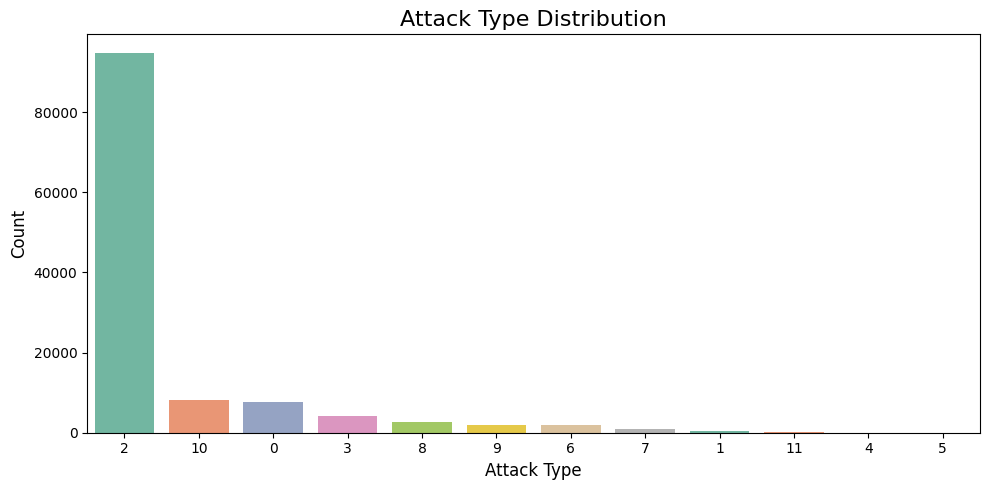

In [23]:
#first plot
plt.figure(figsize=(10,5))
sns.countplot(x='Attack_type', data=analysis_df, palette="Set2", order=analysis_df['Attack_type'].value_counts().index)
plt.title("Attack Type Distribution", fontsize=16)
plt.xlabel("Attack Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

I use this plot because I base in the dataset and i think is the one of the best plot to show the dataset, to show how many records belong to each attack type. This is helpful because it lets us see which attacks appear the most in the dataset. It also helps us understand if the dataset is balanced or if some attacks appear more than others.


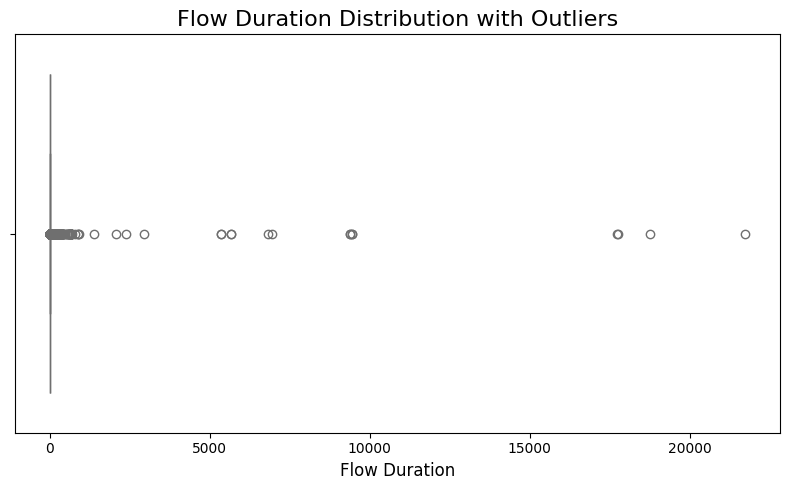

In [24]:
#second plot
plt.figure(figsize=(8,5))
sns.boxplot(x=analysis_df['flow_duration'], color="skyblue")
plt.title("Flow Duration Distribution with Outliers", fontsize=16)
plt.xlabel("Flow Duration", fontsize=12)
plt.tight_layout()
plt.show()

I used a histogram to see how the flow duration values are distributed in the dataset. This helps me understand how long network connections usually last. It can also help detect unusual values that may represent abnormal network behavior.

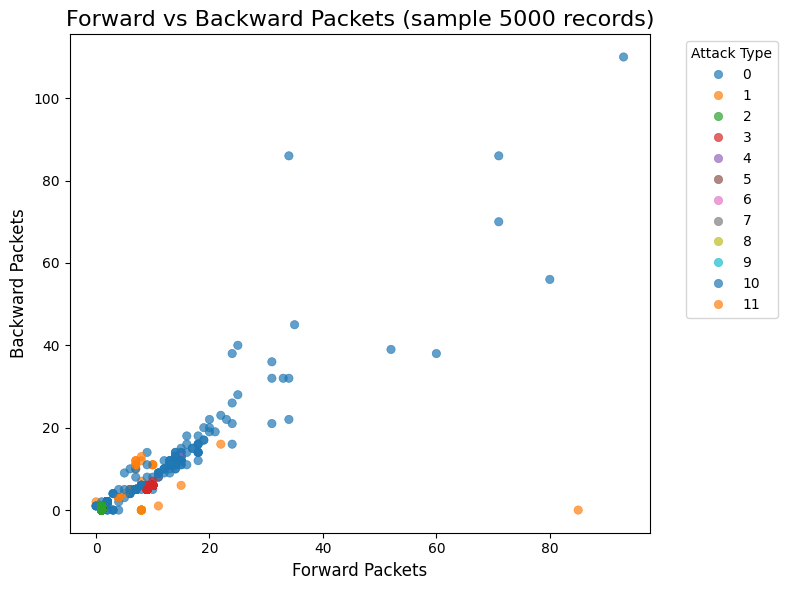

In [25]:
#third plot
plt.figure(figsize=(8,6))
# use Attack_type as hue to show different attack classes
sns.scatterplot(
    x='fwd_pkts_tot',
    y='bwd_pkts_tot',
    data=analysis_df.sample(5000),  # sample for performance
    hue='Attack_type',
    palette='tab10',
    alpha=0.7,
    edgecolor=None
)
plt.title("Forward vs Backward Packets (sample 5000 records)", fontsize=16)
plt.xlabel("Forward Packets", fontsize=12)
plt.ylabel("Backward Packets", fontsize=12)
plt.legend(title="Attack Type", bbox_to_anchor=(1.05,1), loc=2)
plt.tight_layout()
plt.show()

I used a scatter plot to compare the number of forward packets and backward packets. This helps us see if there is a relationship between packets sent and received. Unusual patterns may indicate suspicious network activity.

**Conclusion**

This midterm quiz help me a lot in applying the lessons into a practical situition.I do ETL pipeline the dataset has network traffic data with different types of attacks, and i first cleaned it by removing duplicates, empty cells, and converting text into numbers. I used a bar plot to see how many records each attack type has, a box plot to check flow duration and find unusual values, and a scatter plot to see the relationship between forward and backward packets. These plots helped me understand the dataset better and find patterns in the network traffic. Cleaning the data and using these plots made it easier to analyze and learn about IoT attacks.